In [1]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
import calendar

In [4]:
sales_train = pd.read_csv("DA2024_train.csv", parse_dates = ['Date'], infer_datetime_format = True, low_memory = False)
store_data = pd.read_csv("DA2024_stores.csv")
train_added = pd.read_csv("DA2024_train_added.csv", parse_dates = ['Date'], infer_datetime_format = True, low_memory = False)

In [15]:
test = pd.read_csv('DA2024_test.csv',parse_dates = ['Date'], infer_datetime_format = True, low_memory = False)
test = pd.merge(test, store_data, on = 'Store', how='left')
test

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Unnamed: 10,Unnamed: 11
0,1,4,2015-09-17,NaN,NaN,1.0,1,0,0,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN,NaN,
1,3,4,2015-09-17,NaN,NaN,1.0,1,0,0,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct",NaN,NaN
2,7,4,2015-09-17,NaN,NaN,1.0,1,0,0,a,c,24000.0,4.0,2013.0,0,NaN,NaN,NaN,NaN,NaN
3,8,4,2015-09-17,NaN,NaN,1.0,1,0,0,a,a,7520.0,10.0,2014.0,0,NaN,NaN,NaN,NaN,NaN
4,9,4,2015-09-17,NaN,NaN,1.0,1,0,0,a,c,2030.0,8.0,2000.0,0,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41083,1111,6,2015-08-01,NaN,NaN,1.0,0,0,0,a,a,1900.0,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct",NaN,NaN
41084,1112,6,2015-08-01,NaN,NaN,1.0,0,0,0,c,c,1880.0,4.0,2006.0,0,NaN,NaN,NaN,NaN,NaN
41085,1113,6,2015-08-01,NaN,NaN,1.0,0,0,0,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN
41086,1114,6,2015-08-01,NaN,NaN,1.0,0,0,0,a,c,870.0,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN


In [16]:
train_added = train_added.sort_values(by=['Date','Store']).reset_index(drop=True)
test = test.sort_values(by=['Date','Store']).reset_index(drop=True)

In [131]:
# Iterate through each row of the PromoInterval column
promo_months_list = []
for index, row in train_added.iterrows():
    promo_interval = row['PromoInterval']
    if pd.notna(promo_interval):
        promo_months = promo_interval.split(',')
        
    else:
        # If the value is NaN, assign a list of NaNs
        promo_months = [pd.NA]
    promo_months_list.append(promo_months)
train_added['PromoMonths'] = promo_months_list

In [17]:
# Iterate through each row of the PromoInterval column
promo_months_list = []
for index, row in test.iterrows():
    promo_interval = row['PromoInterval']
    if pd.notna(promo_interval):
        promo_months = promo_interval.split(',')
        
    else:
        # If the value is NaN, assign a list of NaNs
        promo_months = [pd.NA]
    promo_months_list.append(promo_months)
test['PromoMonths'] = promo_months_list

In [18]:
test

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Unnamed: 10,Unnamed: 11,PromoMonths
0,1,6,2015-08-01,NaN,NaN,1.0,0,0,1,c,...,1270.0,9.0,2008.0,0,NaN,NaN,NaN,NaN,,[<NA>]
1,3,6,2015-08-01,NaN,NaN,1.0,0,0,0,a,...,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct",NaN,NaN,"[Jan, Apr, Jul, Oct]"
2,7,6,2015-08-01,NaN,NaN,1.0,0,0,0,a,...,24000.0,4.0,2013.0,0,NaN,NaN,NaN,NaN,NaN,[<NA>]
3,8,6,2015-08-01,NaN,NaN,1.0,0,0,0,a,...,7520.0,10.0,2014.0,0,NaN,NaN,NaN,NaN,NaN,[<NA>]
4,9,6,2015-08-01,NaN,NaN,1.0,0,0,0,a,...,2030.0,8.0,2000.0,0,NaN,NaN,NaN,NaN,NaN,[<NA>]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41083,1111,4,2015-09-17,NaN,NaN,1.0,1,0,0,a,...,1900.0,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct",NaN,NaN,"[Jan, Apr, Jul, Oct]"
41084,1112,4,2015-09-17,NaN,NaN,1.0,1,0,0,c,...,1880.0,4.0,2006.0,0,NaN,NaN,NaN,NaN,NaN,[<NA>]
41085,1113,4,2015-09-17,NaN,NaN,1.0,1,0,0,a,...,9260.0,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,[<NA>]
41086,1114,4,2015-09-17,NaN,NaN,1.0,1,0,0,a,...,870.0,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,[<NA>]


In [143]:
for i in range(4):
    train_added[f'Month{i+1}'] = [promo_months[i] if len(promo_months) > i and pd.notna(promo_months[i]) else pd.NA for promo_months in train_added['PromoMonths']]
   

In [19]:
for i in range(4):
    test[f'Month{i+1}'] = [promo_months[i] if len(promo_months) > i and pd.notna(promo_months[i]) else pd.NA for promo_months in test['PromoMonths']]
   

In [20]:
def find_last_promo_date(row):
    date = row['Date']
    promo_months = [row['Month1'], row['Month2'], row['Month3'], row['Month4']]
    non_nan_months = []
    for month in promo_months:
        if pd.notna(month):
            try:
                month_abbr = month if month != "Sept" else "Sep"
                month_num = list(calendar.month_abbr).index(month_abbr)
                non_nan_months.append(month_num)
            except ValueError:
                pass
    
    if non_nan_months:
        last_promo_date = date
        for month_num in non_nan_months:
            if date.month >= month_num:
                last_promo_date = date.replace(year= date.year, month=month_num, day = 1)
        if date.month < min(non_nan_months):
            try:
                last_promo_date = date.replace(year=date.year-1, month=4, day=1)
            except ValueError:
                # If setting to the 1st day of the 4th month results in an invalid date,
                # set it to the last day of the 3rd month of the previous year instead
                last_promo_date = date.replace(year=date.year-1, month=3, day=calendar.monthrange(date.year-1, 3)[1])
        return last_promo_date
    else:
        return pd.NaT


In [21]:
test['LastCouponSend'] = test.apply(find_last_promo_date, axis=1)

In [23]:
test

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,Promo2SinceYear,PromoInterval,Unnamed: 10,Unnamed: 11,PromoMonths,Month1,Month2,Month3,Month4,LastCouponSend
0,1,6,2015-08-01,NaN,NaN,1.0,0,0,1,c,...,NaN,NaN,NaN,,[<NA>],<NA>,<NA>,<NA>,<NA>,NaT
1,3,6,2015-08-01,NaN,NaN,1.0,0,0,0,a,...,2011.0,"Jan,Apr,Jul,Oct",NaN,NaN,"[Jan, Apr, Jul, Oct]",Jan,Apr,Jul,Oct,2015-07-01
2,7,6,2015-08-01,NaN,NaN,1.0,0,0,0,a,...,NaN,NaN,NaN,NaN,[<NA>],<NA>,<NA>,<NA>,<NA>,NaT
3,8,6,2015-08-01,NaN,NaN,1.0,0,0,0,a,...,NaN,NaN,NaN,NaN,[<NA>],<NA>,<NA>,<NA>,<NA>,NaT
4,9,6,2015-08-01,NaN,NaN,1.0,0,0,0,a,...,NaN,NaN,NaN,NaN,[<NA>],<NA>,<NA>,<NA>,<NA>,NaT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41083,1111,4,2015-09-17,NaN,NaN,1.0,1,0,0,a,...,2013.0,"Jan,Apr,Jul,Oct",NaN,NaN,"[Jan, Apr, Jul, Oct]",Jan,Apr,Jul,Oct,2015-07-01
41084,1112,4,2015-09-17,NaN,NaN,1.0,1,0,0,c,...,NaN,NaN,NaN,NaN,[<NA>],<NA>,<NA>,<NA>,<NA>,NaT
41085,1113,4,2015-09-17,NaN,NaN,1.0,1,0,0,a,...,NaN,NaN,NaN,NaN,[<NA>],<NA>,<NA>,<NA>,<NA>,NaT
41086,1114,4,2015-09-17,NaN,NaN,1.0,1,0,0,a,...,NaN,NaN,NaN,NaN,[<NA>],<NA>,<NA>,<NA>,<NA>,NaT


In [32]:
# Calculate days since last promo for each row
train_added['DaysSinceCoupon'] = (train_added['Date'] - train_added['LastCouponSend']).dt.days

KeyError: 'LastCouponSend'

In [214]:
train_full = train_added.drop(columns=["PromoMonths",'Month1','Month2','Month3','Month4','Promo2SinceWeek','Promo2SinceYear','Promo2SinceDate'])

In [34]:
test_full = test.drop(columns=["PromoMonths",'Month1','Month2','Month3','Month4','PromoInterval','Unnamed: 10','Unnamed: 11'])

In [35]:
test_full = test_full.fillna(0)

In [36]:
test_full.to_csv('test_full.csv')

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,Promo2SinceYear,Promo2SinceDate,PromoInterval,WeeksSinceLastPromo,MonthsSinceLastPromo,YearsSinceLastPromo,Month1,Month 2,Month 3,Month 4
0,1,2,2013-01-01,0,0,0,0,a,1,c,...,NaN,NaN,NaN,,,NaN,NaN,NaN,NaN,NaN
1,2,2,2013-01-01,0,0,0,0,a,1,a,...,2010.0,22/03/2010,"Jan,Apr,Jul,Oct",145,33,2.0,Jan,Apr,Jul,Oct
2,3,2,2013-01-01,0,0,0,0,a,1,a,...,2011.0,28/03/2011,"Jan,Apr,Jul,Oct",92,21,1.0,Jan,Apr,Jul,Oct
3,4,2,2013-01-01,0,0,0,0,a,1,c,...,NaN,NaN,NaN,,,NaN,NaN,NaN,NaN,NaN
4,5,2,2013-01-01,0,0,0,0,a,1,a,...,NaN,NaN,NaN,,,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1017204,1111,5,2015-07-31,5723,422,1,1,0,1,a,...,2013.0,29/07/2013,"Jan,Apr,Jul,Oct",105,24,2.0,Jan,Apr,Jul,Oct
1017205,1112,5,2015-07-31,9626,767,1,1,0,1,c,...,NaN,NaN,NaN,,,NaN,NaN,NaN,NaN,NaN
1017206,1113,5,2015-07-31,7289,720,1,1,0,1,a,...,NaN,NaN,NaN,,,NaN,NaN,NaN,NaN,NaN
1017207,1114,5,2015-07-31,27508,3745,1,1,0,1,a,...,NaN,NaN,NaN,,,NaN,NaN,NaN,NaN,NaN


array([[<Axes: title={'center': 'Sales'}>,
        <Axes: title={'center': 'Customers'}>]], dtype=object)

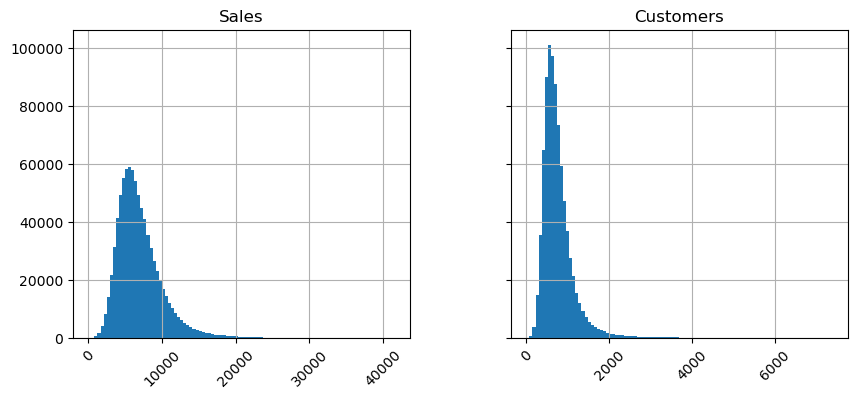

In [8]:
sales_train.query('Open == 1')[['Sales', 'Customers']].hist(bins=100, figsize=(10,4), xrot=45, sharey=True)

<Axes: xlabel='Date'>

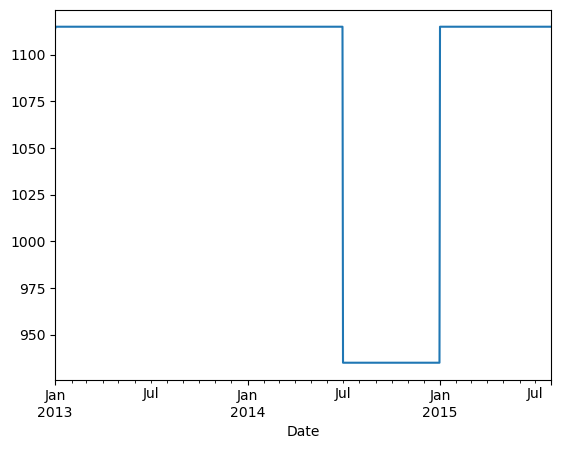

In [9]:
sales_train.groupby('Date')['Store'].size().plot(kind='line')

In [39]:
from datetime import datetime, timedelta

# Define the start and end dates for the specified time period
start_date = datetime(2013, 1, 1)
end_date = datetime(2015, 8, 1)
duration = (end_date - start_date).days

# Initialize a counter for the number of dates with sales for all 1115 stores
dates_with_sales_count = 0

# Iterate over the dates within the specified time period
current_date = start_date
while current_date <= end_date:
    # Check if there are sales records for all 1115 stores on the current date
    has_sales_all_stores = len(sales_train[(sales_train['Date'] == current_date) & 
                                      (sales_train['Store'].isin(range(1, 1116)))]) == 1115
    
    # If there are sales records for all 1115 stores on the current date, increment the counter
    if has_sales_all_stores:
        dates_with_sales_count += 1
    
    # Move to the next date
    current_date += timedelta(days=1)

print("Number of dates with sales for all 1115 stores:", dates_with_sales_count)
print("Total no of dates:", duration)

Number of dates with sales for all 1115 stores: 757
Total no of dates: 942


In [19]:
def add_missing_dates(train, all_stores):
    train_m = pd.DataFrame()
    
    for store in all_stores:
        # Check if the store has sales data for the second half of 2014
        has_sales_2nd_half_2014 = len(train[(train['Store'] == store) & 
                                              (train['Date'] >= '2014-07-01') & 
                                              (train['Date'] <= '2014-12-31')]) > 0
        
        # If the store doesn't have sales data for the second half of 2014, impute sales using data from one year ago
        if not has_sales_2nd_half_2014:
            # Get the sales data from exactly one year ago for the current store
            sales_one_year_ago = train[(train['Store'] == store) & 
                                       (train['Date'] >= '2013-07-01') & 
                                       (train['Date'] <= '2013-12-31')]
            
            # Update the date to correspond to the second half of 2014
            sales_one_year_ago['Date'] += pd.DateOffset(years=1)
            
            # Append the imputed sales data to the train_m DataFrame
            train_m = pd.concat([train_m, sales_one_year_ago], ignore_index=True)
    
    # Add DayOfWeek column
    train_m['DayOfWeek'] = train_m['Date'].dt.dayofweek + 1
    
    # Reorder columns
    train_m = train_m[['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday']]
    
    return train_m

In [25]:
# Call the function to impute missing sales data
imputed_missing = add_missing_dates(sales_train, set(store_data.Store))
imputed_missing

C:\Users\PC\AppData\Local\Temp\ipykernel_26236\2964698304.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sales_one_year_ago['Date'] += pd.DateOffset(years=1)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,13,3,2014-12-31,2762,253,1,0,0,1
1,13,2,2014-12-30,5672,482,1,0,0,1
2,13,1,2014-12-29,0,0,0,0,0,0
3,13,7,2014-12-28,3886,379,1,0,0,0
4,13,6,2014-12-27,4711,409,1,0,0,1
...,...,...,...,...,...,...,...,...,...
33115,1109,6,2014-07-05,5568,509,1,1,0,0
33116,1109,5,2014-07-04,5678,502,1,1,0,0
33117,1109,4,2014-07-03,5697,507,1,1,0,0
33118,1109,3,2014-07-02,5391,485,1,1,0,0


In [48]:
stores_without_sales = []

for store in set(store_data.Store):
    # Check if the store has sales data for the second half of 2014
    has_sales_2nd_half_2014 = len(sales_train[(sales_train['Store'] == store) & 
                                          (sales_train['Date'] >= '2014-07-01') & 
                                          (sales_train['Date'] <= '2014-12-31')]) == 0
    
    # If the store doesn't have sales data for the second half of 2014, add it to the list
    if has_sales_2nd_half_2014:
        stores_without_sales.append(store)


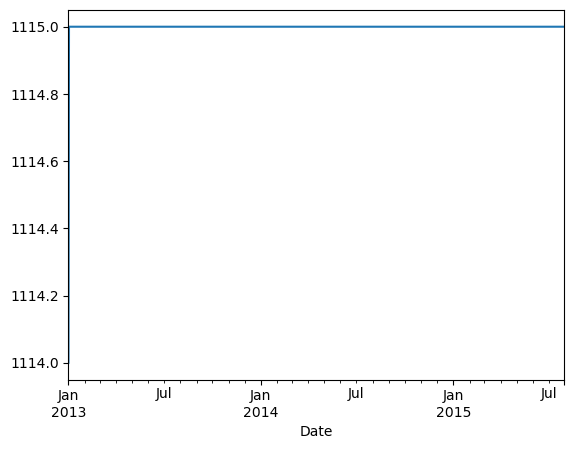

In [216]:
imputed_train = pd.concat([train_full, imputed_missing])
imputed_train.groupby('Date')['Store'].size().plot(kind='line');

In [220]:
imputed_train = imputed_train.fillna(0)
imputed_train = imputed_train.sort_values(by =['Date','Store'])

In [223]:
imputed_train.to_csv('Imputed_train.csv', index=False)

In [224]:
test = pd.read_csv('DA2024_test.csv')